<a href="https://colab.research.google.com/github/Spandana331/AIML_2026/blob/main/Lab_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Questions:
#Experiment with different transformation matrices and check the accuracy
#Will the same transform used for these two features also work for other features?
Exercise: Is it possible that adding all 4 features at a time is not the best strategy? Can you think of a better combination of features that can help in improving the accuracy of the model? Maybe you can try adding 2 features at a time and see if that helps.

In [1]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [10]:
# Load dataset
iris = datasets.load_iris()

In [11]:
# Select two features (petal length and petal width)
X = iris.data[:, [2,3]]
y = iris.target

In [12]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
# KNN model
knn = KNeighborsClassifier(n_neighbors=5)

In [14]:
# ---------------- Original Data ----------------
knn.fit(X_train, y_train)
original_accuracy = knn.score(X_test, y_test)

print("Original Accuracy:", original_accuracy)

Original Accuracy: 1.0


In [15]:
# ---------------- Identity Matrix ----------------
identity = np.array([[1,0],[0,1]])

X_train_id = X_train.dot(identity)
X_test_id = X_test.dot(identity)

knn.fit(X_train_id, y_train)
identity_accuracy = knn.score(X_test_id, y_test)

print("Identity Matrix Accuracy:", identity_accuracy)

Identity Matrix Accuracy: 1.0


In [16]:
# ---------------- Scaling Matrix ----------------
scaling = np.array([[2,0],[0,1]])

X_train_scale = X_train.dot(scaling)
X_test_scale = X_test.dot(scaling)

knn.fit(X_train_scale, y_train)
scaling_accuracy = knn.score(X_test_scale, y_test)

print("Scaling Matrix Accuracy:", scaling_accuracy)

Scaling Matrix Accuracy: 1.0


In [17]:
# ---------------- Rotation Matrix ----------------
rotation = np.array([[0,-1],[1,0]])

X_train_rot = X_train.dot(rotation)
X_test_rot = X_test.dot(rotation)

knn.fit(X_train_rot, y_train)
rotation_accuracy = knn.score(X_test_rot, y_test)

print("Rotation Matrix Accuracy:", rotation_accuracy)

Rotation Matrix Accuracy: 1.0


#Will the same transform used for these two features also work for other features?

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


In [20]:
# Load Kaggle Iris Dataset
data = pd.read_csv("/content/iris.data")

In [22]:
# Convert species to numeric
data = pd.read_csv("/content/iris.data", header=None)
data.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'Species']
data['Species'] = data['Species'].astype('category').cat.codes

In [25]:
# Feature combinations
feature_sets = {
    "Petal Length & Petal Width": ['petal_length', 'petal_width'],
    "Sepal Length & Sepal Width": ['sepal_length', 'sepal_width'],
    "Sepal Length & Petal Length": ['sepal_length', 'petal_length']
}

In [26]:
# Same Transformation Matrix (Scaling)
transform_matrix = np.array(
    [[2, 0],
     [0, 1]]
)

knn = KNeighborsClassifier(n_neighbors=5)

accuracies = {}

for name, features in feature_sets.items():

    X = data[features].values
    y = data['Species'].values

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Apply transformation
    X_train_transformed = X_train.dot(transform_matrix)
    X_test_transformed = X_test.dot(transform_matrix)

    # Train and evaluate model
    knn.fit(X_train_transformed, y_train)
    accuracy = knn.score(X_test_transformed, y_test)
    accuracies[name] = accuracy

print("Accuracies with Scaling Matrix:")
for name, accuracy in accuracies.items():
    print(f"  {name}: {accuracy:.2f}")

Accuracies with Scaling Matrix:
  Petal Length & Petal Width: 1.00
  Sepal Length & Sepal Width: 0.83
  Sepal Length & Petal Length: 0.93


In [28]:
# Apply same transform
X_transformed = X.dot(transform_matrix)

X_train, X_test, y_train, y_test = train_test_split(
    X_transformed, y, test_size=0.2, random_state=42
)

knn.fit(X_train, y_train)
acc = knn.score(X_test, y_test)

accuracies[name] = acc

print(name, "Accuracy:", acc)

print("\nFinal Accuracies:")
print(accuracies)

Sepal Length & Petal Length Accuracy: 0.9333333333333333

Final Accuracies:
{'Petal Length & Petal Width': 1.0, 'Sepal Length & Sepal Width': 0.8333333333333334, 'Sepal Length & Petal Length': 0.9333333333333333}


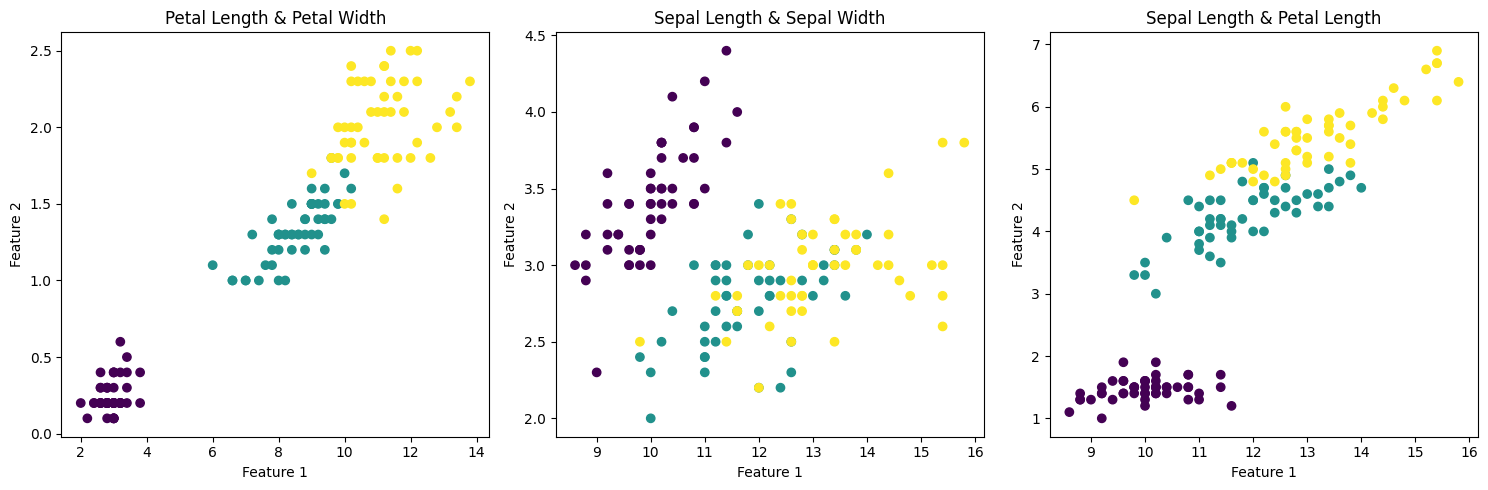

In [29]:
# Visualization of Feature Transformations

plt.figure(figsize=(15,5))

i = 1

for name, features in feature_sets.items():

    X = data[features].values
    y = data['Species'].values

    X_transformed = X.dot(transform_matrix)

    plt.subplot(1,3,i)
    plt.scatter(X_transformed[:,0], X_transformed[:,1], c=y)
    plt.title(name)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    i += 1

plt.tight_layout()
plt.show()

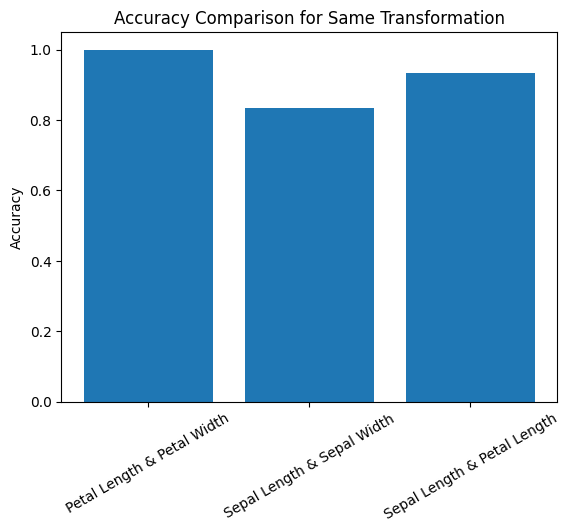

In [30]:
# Accuracy Bar Chart

names = list(accuracies.keys())
values = list(accuracies.values())

plt.figure()
plt.bar(names, values)
plt.xticks(rotation=30)
plt.title("Accuracy Comparison for Same Transformation")
plt.ylabel("Accuracy")
plt.show()

#Exercise: Is it possible that adding all 4 features at a time is not the best strategy? Can you think of a better combination of features that can help in improving the accuracy of the model? Maybe you can try adding 2 features at a time and see if that helps.



In [31]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


In [34]:
# Load Kaggle dataset
data = pd.read_csv("/content/iris.data", header=None)
data.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'Species']

In [35]:
# Convert species to numeric
data['Species'] = data['Species'].astype('category').cat.codes

In [38]:
# Features
features = ['sepal_length','sepal_width','petal_length','petal_width']

y = data['Species']

knn = KNeighborsClassifier(n_neighbors=5)

accuracy_results = {}

In [39]:
# Using all 4 features
X_all = data[features]

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

knn.fit(X_train, y_train)
all_accuracy = knn.score(X_test, y_test)

accuracy_results["All 4 Features"] = all_accuracy

print("All 4 Features Accuracy:", all_accuracy)

All 4 Features Accuracy: 1.0


In [44]:
# Explore combinations of 2 features
for combo in itertools.combinations(features, 2):
    current_features = list(combo)
    X_combo = data[current_features]

    X_train, X_test, y_train, y_test = train_test_split(
        X_combo, y, test_size=0.2, random_state=42
    )

    knn.fit(X_train, y_train)
    combo_accuracy = knn.score(X_test, y_test)

    accuracy_results[f"{current_features[0]} & {current_features[1]}"] = combo_accuracy

    print(f"{current_features[0]} & {current_features[1]} Accuracy: {combo_accuracy}")

print("\nAccuracy Results:")
for name, acc in accuracy_results.items():
    print(f"  {name}: {acc:.3f}")

sepal_length & sepal_width Accuracy: 0.8
sepal_length & petal_length Accuracy: 0.9666666666666667
sepal_length & petal_width Accuracy: 0.9666666666666667
sepal_width & petal_length Accuracy: 0.9666666666666667
sepal_width & petal_width Accuracy: 1.0
petal_length & petal_width Accuracy: 1.0

Accuracy Results:
  All 4 Features: 1.000
  sepal_length & sepal_width: 0.800
  sepal_length & petal_length: 0.967
  sepal_length & petal_width: 0.967
  sepal_width & petal_length: 0.967
  sepal_width & petal_width: 1.000
  petal_length & petal_width: 1.000
  ('sepal_length', 'sepal_width'): 0.800
  ('sepal_length', 'petal_length'): 0.967
  ('sepal_length', 'petal_width'): 0.967
  ('sepal_width', 'petal_length'): 0.967
  ('sepal_width', 'petal_width'): 1.000
  ('petal_length', 'petal_width'): 1.000


In [41]:
# Trying 2 feature combinations
for combo in itertools.combinations(features, 2):

    X = data[list(combo)]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    knn.fit(X_train, y_train)
    acc = knn.score(X_test, y_test)

    accuracy_results[str(combo)] = acc

    print(combo, "Accuracy:", acc)


print("\nFinal Accuracy Results")
print(accuracy_results)

('sepal_length', 'sepal_width') Accuracy: 0.8
('sepal_length', 'petal_length') Accuracy: 0.9666666666666667
('sepal_length', 'petal_width') Accuracy: 0.9666666666666667
('sepal_width', 'petal_length') Accuracy: 0.9666666666666667
('sepal_width', 'petal_width') Accuracy: 1.0
('petal_length', 'petal_width') Accuracy: 1.0

Final Accuracy Results
{'All 4 Features': 1.0, 'sepal_length & sepal_width': 0.8, 'sepal_length & petal_length': 0.9666666666666667, 'sepal_length & petal_width': 0.9666666666666667, 'sepal_width & petal_length': 0.9666666666666667, 'sepal_width & petal_width': 1.0, 'petal_length & petal_width': 1.0, "('sepal_length', 'sepal_width')": 0.8, "('sepal_length', 'petal_length')": 0.9666666666666667, "('sepal_length', 'petal_width')": 0.9666666666666667, "('sepal_width', 'petal_length')": 0.9666666666666667, "('sepal_width', 'petal_width')": 1.0, "('petal_length', 'petal_width')": 1.0}


#Visualization Code
1. Accuracy Comparison Bar Chart

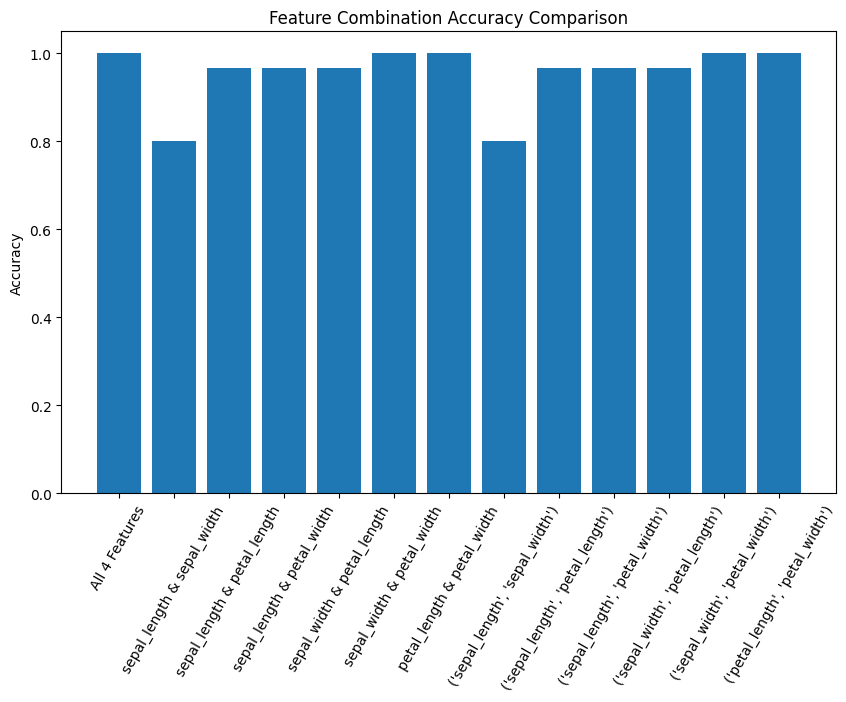

In [42]:
names = list(accuracy_results.keys())
values = list(accuracy_results.values())

plt.figure(figsize=(10,6))
plt.bar(names, values)
plt.xticks(rotation=60)
plt.ylabel("Accuracy")
plt.title("Feature Combination Accuracy Comparison")
plt.show()

2. Best Feature Visualization

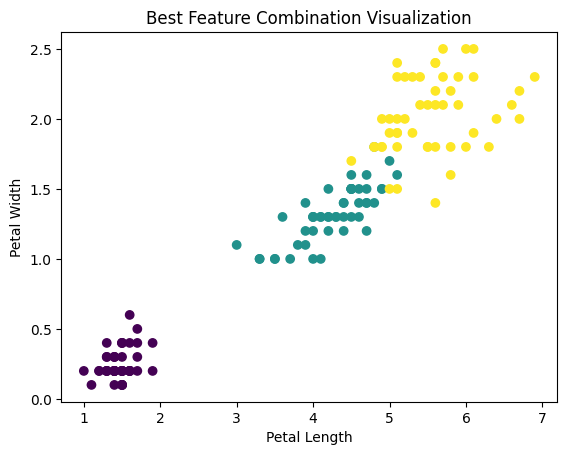

In [45]:
X = data[['petal_length','petal_width']]
y = data['Species']

plt.figure()
plt.scatter(X['petal_length'], X['petal_width'], c=y)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Best Feature Combination Visualization")
plt.show()

#Experiment with transforms: Try [[2, 0], [0, 0.5]] - what happens to accuracy?

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [49]:

# Load Kaggle Iris dataset
data = pd.read_csv("/content/iris.data", header=None)
data.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'Species']

In [50]:
# Convert species to numeric
data['Species'] = data['Species'].astype('category').cat.codes

In [51]:
# Define the new transformation matrix
transform_matrix = np.array([[2, 0], [0, 0.5]])

# Select the best performing features (petal length and petal width)
X = data[['petal_length', 'petal_width']].values
y = data['Species'].values

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply the transformation
X_train_transformed = X_train.dot(transform_matrix)
X_test_transformed = X_test.dot(transform_matrix)

# KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train and evaluate model
knn.fit(X_train_transformed, y_train)
new_transform_accuracy = knn.score(X_test_transformed, y_test)

print(f"Accuracy with transform [[2, 0], [0, 0.5]]: {new_transform_accuracy:.3f}")

Accuracy with transform [[2, 0], [0, 0.5]]: 1.000


In [52]:

# KNN without transform
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
original_accuracy = knn.score(X_test, y_test)

print("Original Accuracy:", original_accuracy)

Original Accuracy: 1.0


In [53]:
# Transformation Matrix
transform_matrix = np.array([
    [2, 0],
    [0, 0.5]
])


In [54]:
# Apply transform
X_train_transformed = X_train.dot(transform_matrix)
X_test_transformed = X_test.dot(transform_matrix)


In [55]:
# Train again
knn.fit(X_train_transformed, y_train)
transformed_accuracy = knn.score(X_test_transformed, y_test)


In [56]:
print("Transformed Accuracy:", transformed_accuracy)

Transformed Accuracy: 1.0


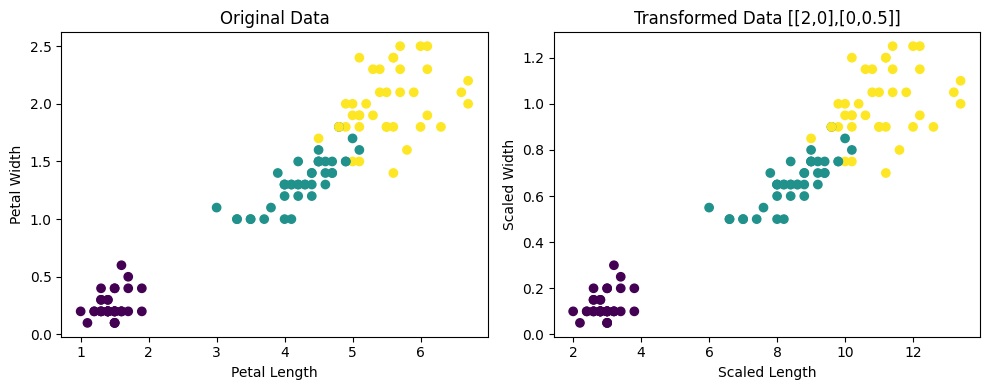

In [57]:
# Visualization

plt.figure(figsize=(10,4))

# Original
plt.subplot(1,2,1)
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)
plt.title("Original Data")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

# Transformed
plt.subplot(1,2,2)
plt.scatter(X_train_transformed[:,0], X_train_transformed[:,1], c=y_train)
plt.title("Transformed Data [[2,0],[0,0.5]]")
plt.xlabel("Scaled Length")
plt.ylabel("Scaled Width")

plt.tight_layout()
plt.show()